In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# Paths
# lxplus_signal = "lxplus_signal"
final_signals = "replicate_deepak"
# final_signals = "final_signals_no_muons"

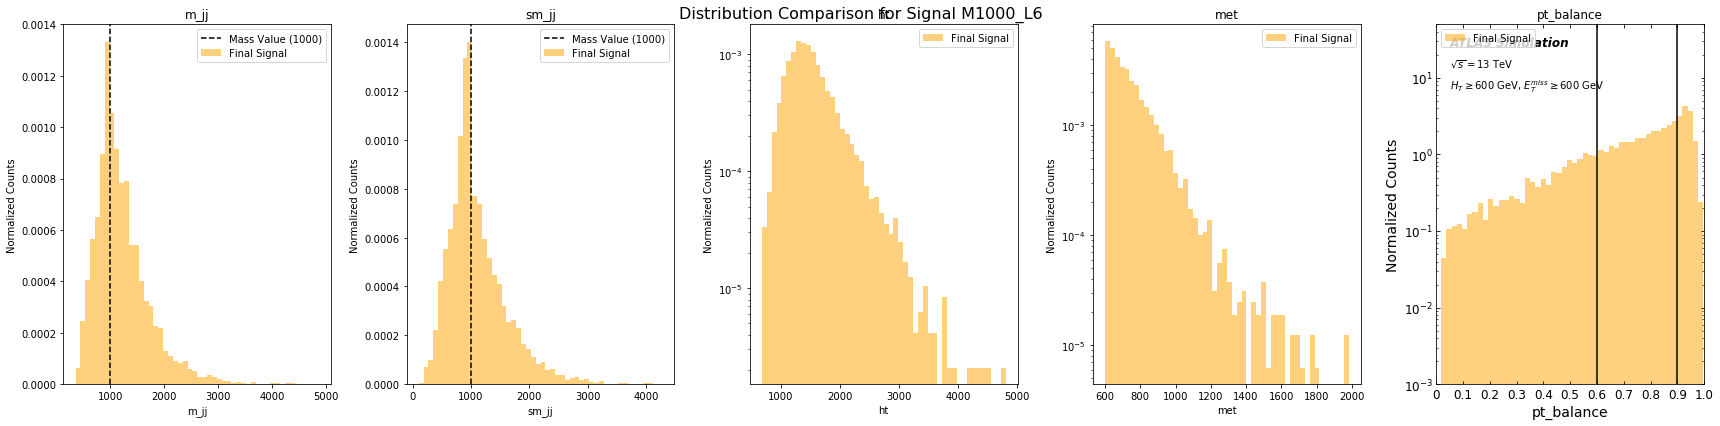

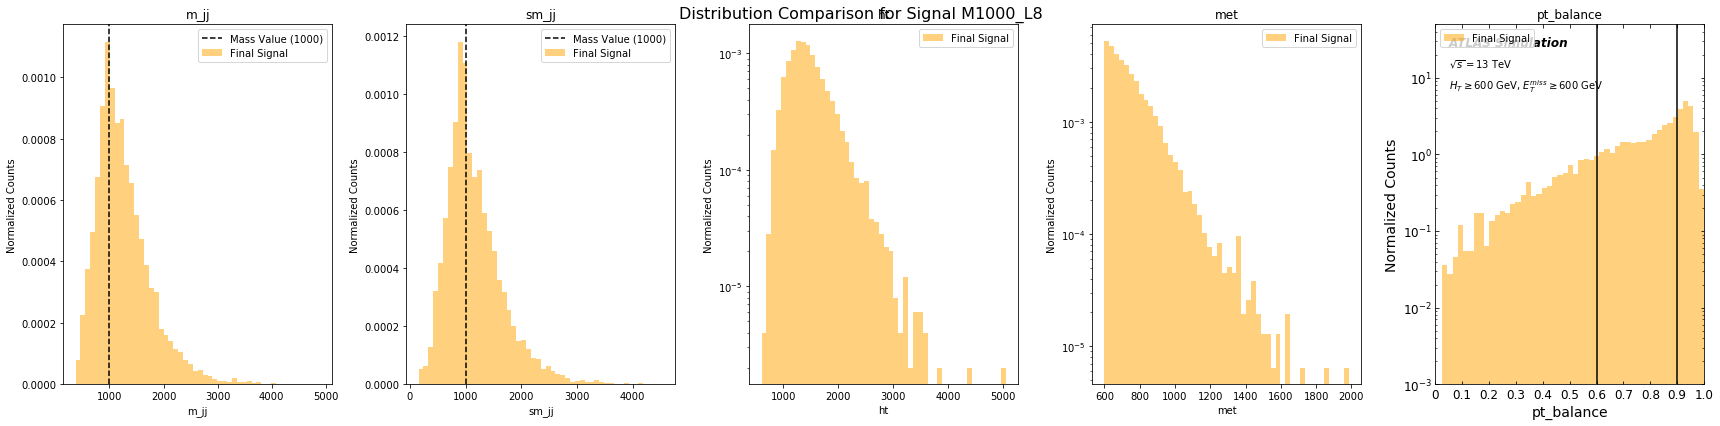

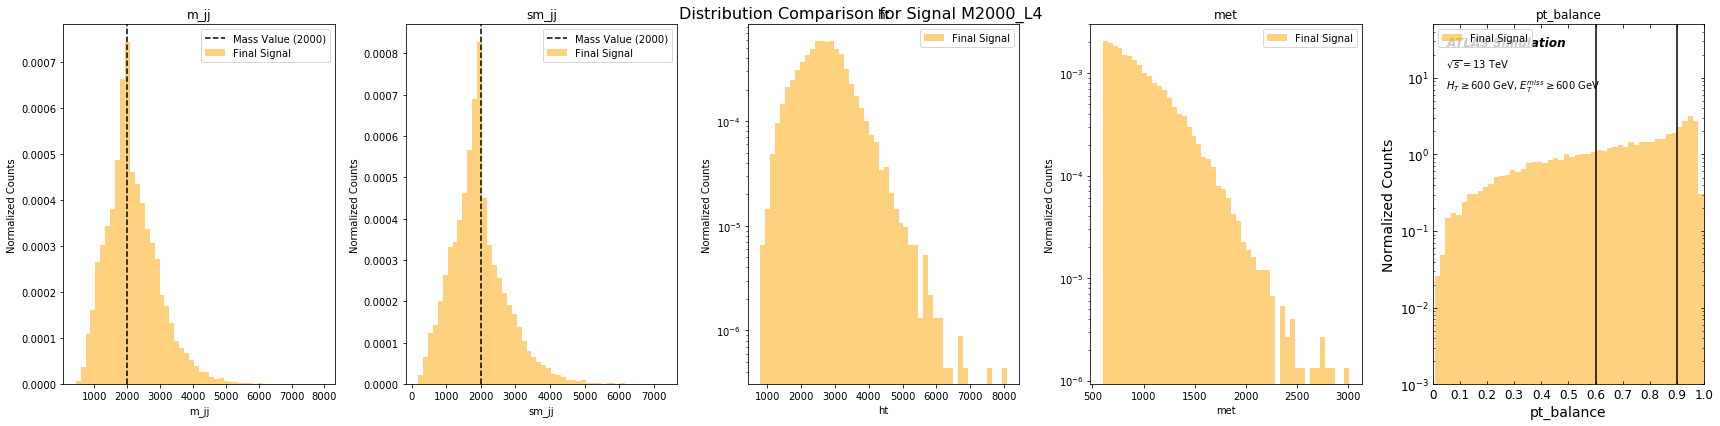

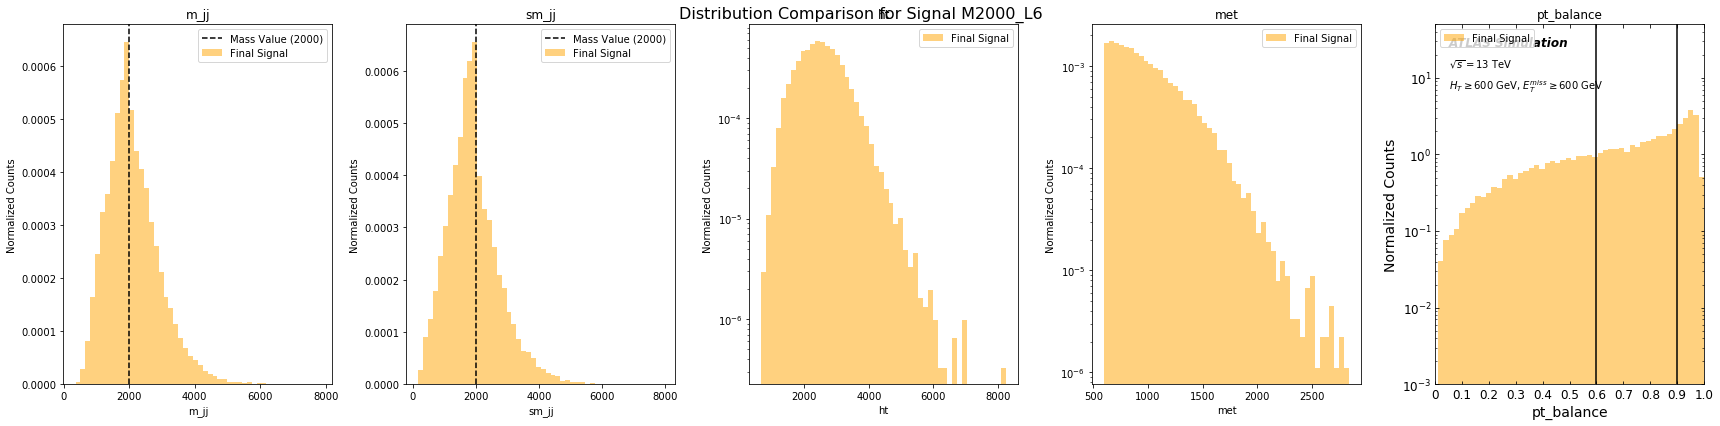

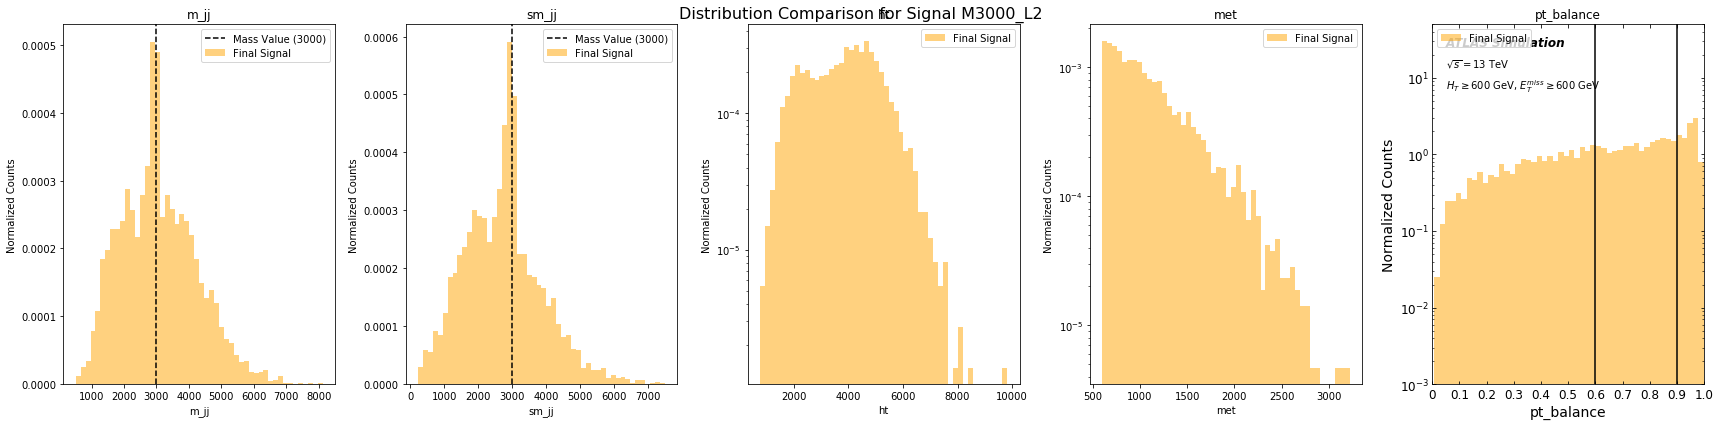

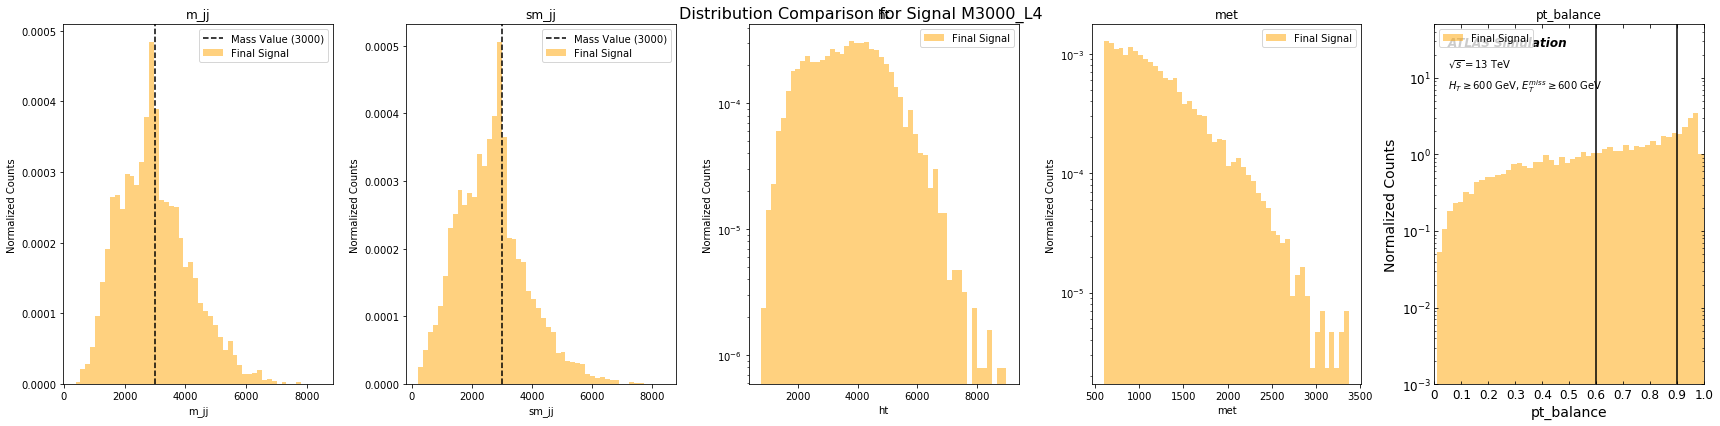

In [2]:
signal_modes = ["1000_6", "1000_8", "2000_4", "2000_6", "3000_2", "3000_4"]
plot_vars = ['m_jj', 'sm_jj', 'ht', 'met', 'pt_balance']

for mode in signal_modes:
    mass, rinv = mode.split('_')
    # file_name_lxplus = f"{mass}_{rinv}_events.txt"
    file_name_final = f"{mass}_{rinv}_events_markI.txt"

    # path_lxplus = os.path.join(lxplus_signal, file_name_lxplus)
    path_final = os.path.join(final_signals, file_name_final)

    # Read data
    # df_lxplus = pd.read_csv(path_lxplus, delim_whitespace=True)
    df_final = pd.read_csv(path_final, delim_whitespace=True)
    df_final = df_final[
            (df_final['ht'] >= 600) & 
            (df_final['met'] >= 600)
        ]

    # Create a figure with 4 subplots side-by-side
    fig, axes = plt.subplots(1, 5, figsize=(24, 6))
    fig.suptitle(f'Distribution Comparison for Signal M{mass}_L{rinv}', fontsize=16)

    for ax, var_comp in zip(axes, plot_vars):
        # Plot histograms
        # if var_comp in ['pt_balance', 'sm_jj']:
            # continue

        # ax.hist(df_lxplus[var_comp], bins=50, alpha=0.5, label='LXPLUS Signal', color='blue', density=True)
        ax.hist(df_final[var_comp], bins=50, alpha=0.5, label='Final Signal', color='orange', density=True)
        
        # Add mass line only for m_jj (since mass value specifically corresponds to invariant mass)
        if var_comp in ['m_jj', 'sm_jj']:
            ax.axvline(x=float(mass), color='black', linestyle='--', label=f'Mass Value ({mass})')
        
        if var_comp == 'pt_balance':
            # --- 1. Log Scale & Limits ---
            ax.set_yscale('log')
            ax.set_xlim(0, 1)
            ax.set_ylim(1e-3, 50)  # Adjust 50 based on your highest peak

            # --- 2. Labels ---
            ax.set_xlabel(r'$p_T^{bal}$', fontsize=14)
            ax.set_ylabel('Fraction of events / 0.05', fontsize=14)

            # --- 3. Vertical Cut Lines ---
            ax.axvline(x=0.6, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0.9, color='black', linestyle='-', linewidth=1.5)

            # --- 4. ATLAS Text Overlay ---
            ax.text(0.05, 0.94, 'ATLAS Simulation', transform=ax.transAxes,
                    fontsize=12, fontweight='bold', style='italic')
            ax.text(0.05, 0.88, r'$\sqrt{s} = 13$ TeV', transform=ax.transAxes, fontsize=10)
            ax.text(0.05, 0.82, r'$H_T \geq 600$ GeV, $E_T^{miss} \geq 600$ GeV',
                    transform=ax.transAxes, fontsize=10)

            # --- 5. Ticks Formatting ---
            ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
            ax.set_xticks(np.arange(0, 1.1, 0.1))
            ax.set_xticklabels(['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])
        
        elif var_comp in ["met", "ht"]:
            # Keep simple log scale for other vars
            ax.semilogy()
        
        ax.set_title(f'{var_comp}')
        ax.set_xlabel(f'{var_comp}')
        ax.set_ylabel('Normalized Counts')
        ax.legend()

    plt.tight_layout()
    plt.show()


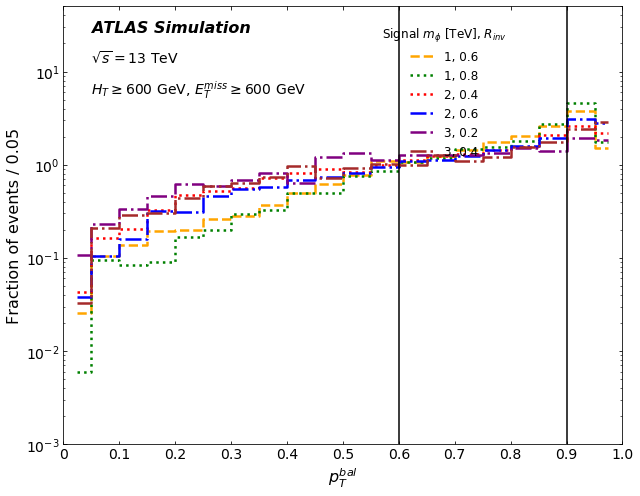

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 1. Define the specific modes you want to plot
target_modes = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

# 2. Define styling to match the ATLAS image
styles = {
    '1000_6': ('orange', '--'),      # 1 TeV, 0.6
    '1000_8': ('green', ':'),        # 1 TeV, 0.8
    '2000_4': ('red', ':'),          # 2 TeV, 0.4
    '2000_6': ('blue', '-.'),        # 2 TeV, 0.6
    '3000_2': ('purple', '-.'),      # 3 TeV, 0.2
    '3000_4': ('brown', '-.')        # 3 TeV, 0.4
}

# Define bins (0 to 1 with 0.05 width)
bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Create the figure
plt.figure(figsize=(9, 7))
ax = plt.gca()

for mode in target_modes:
    mass, rinv = mode.split('_')
    file_name_final = f"{mass}_{rinv}_events.txt"
    path_final = os.path.join(final_signals, file_name_final)

    try:
        # Read data
        df_final = pd.read_csv(path_final, delim_whitespace=True)
        
        # --- SCREENING / CUTS ---
        # Apply HT >= 600 and MET >= 600 cuts
        # Ensure column names match your file (e.g., 'ht', 'met' or 'HT', 'MET')
        df_screened = df_final[
            (df_final['ht'] >= 600) & 
            (df_final['met'] >= 600)
        ]
        # df_screened = df_final
        
        # If no events pass the cut, skip to avoid errors
        if df_screened.empty:
            print(f"Warning: No events passed cuts for {mode}")
            continue

        data_to_plot = df_screened['pt_balance']

        # Calculate Histogram
        counts, _ = np.histogram(data_to_plot, bins=bins, density=True)
        # Get style
        color, linestyle = styles.get(mode, ('black', '-'))

        # Format Label (m=1, r=0.6)
        label_m = int(mass) // 1000
        # Convert rinv string (e.g. '6') to float display (0.6)
        display_rinv = float(rinv) / 10 if len(rinv) == 1 else float(rinv)
        label = f"{label_m}, {display_rinv}"

        # Plot
        plt.plot(bin_centers, counts, 
                 drawstyle='steps-mid', 
                 color=color, 
                 linestyle=linestyle, 
                 linewidth=2.5, 
                 label=label)

    except FileNotFoundError:
        print(f"File not found: {path_final}")
    except KeyError as e:
        print(f"Column name error in {mode}: {e}")

# --- Final Decorations ---
# Vertical cut lines
plt.axvline(x=0.6, color='black', linestyle='-', linewidth=1.5)
plt.axvline(x=0.9, color='black', linestyle='-', linewidth=1.5)

# Axis & Scale
plt.yscale('log')
plt.ylim(1e-3, 50) 
plt.xlim(0, 1)
plt.xlabel(r'$p_T^{bal}$', fontsize=16)
plt.ylabel('Fraction of events / 0.05', fontsize=16)

# ATLAS Text
plt.text(0.05, 0.94, 'ATLAS Simulation', transform=ax.transAxes,
            fontsize=16, fontweight='bold', style='italic')
plt.text(0.05, 0.87, r'$\sqrt{s} = 13$ TeV', transform=ax.transAxes, fontsize=14)
plt.text(0.05, 0.80, r'$H_T \geq 600$ GeV, $E_T^{miss} \geq 600$ GeV', transform=ax.transAxes, fontsize=14)

# Legend
legend = plt.legend(title=r'Signal $m_{\phi}$ [TeV], $R_{inv}$', 
           loc='upper left', 
           bbox_to_anchor=(0.55, 0.98), 
           frameon=False, 
           fontsize=12)
plt.setp(legend.get_title(), fontsize=12)

# Ticks
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

plt.tight_layout()
plt.show()